In [1]:
import pandas as pd

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv")
ORIG = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")
print(train_data.shape)
print(test_df.shape)
print(ORIG.shape)

(439140, 16)
(188165, 15)
(101371, 16)


In [3]:
ORIG.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [4]:
ORIG["Compound"] = ORIG["Compound"].fillna("UNKNOWN")

In [5]:
train_data = pd.concat([train_data, ORIG], ignore_index=True)

In [6]:
print("Train data:",train_data.columns.tolist())
print("Test data:",test_df.columns.tolist())

Train data: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'Normalized_TyreLife']
Test data: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


In [7]:
print(train_data.isnull().sum())
train_data = train_data.drop(columns=["Normalized_TyreLife"])

id                        101371
Driver                         0
Compound                       0
Race                           0
Year                           0
PitStop                        0
LapNumber                      0
Stint                          0
TyreLife                       0
Position                       0
LapTime (s)                    0
LapTime_Delta                  0
Cumulative_Degradation         0
RaceProgress                   0
Position_Change                0
PitNextLap                     0
Normalized_TyreLife       439140
dtype: int64


In [8]:
train_data.shape

(540511, 16)

In [9]:
train_data['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET', 'UNKNOWN'],
      dtype=object)

In [10]:
train_data['Compound'] = train_data['Compound'].str.upper().str.strip()
test_df['Compound'] = test_df['Compound'].str.upper().str.strip()

In [11]:
compound_map = {
    'SOFT': 0,
    'MEDIUM': 1,
    'HARD': 2,
    'INTERMEDIATE': 3,
    'WET': 4
}

train_data['Compound'] = train_data['Compound'].map(compound_map)
test_df['Compound'] = test_df['Compound'].map(compound_map)

train_data['Compound']

0         2.0
1         2.0
2         2.0
3         1.0
4         2.0
         ... 
540506    2.0
540507    2.0
540508    2.0
540509    2.0
540510    2.0
Name: Compound, Length: 540511, dtype: float64

In [12]:
train_data['Compound'].isnull().sum()

np.int64(66)

In [13]:
def feature_eng(train_data):
    train_data['PrevLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].shift(1))
    train_data['PrevPosition'] = (
        train_data.groupby('Driver')['Position'].shift(1))
    train_data['RollingLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].rolling(3).mean().reset_index(0, drop=True))
    train_data['TyreLife_x_Compound'] = (
        train_data['TyreLife'] * train_data['Compound']
    )
    return train_data

In [14]:
feature_eng(train_data)
feature_eng(test_df)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,439140,D119,1,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0,NaN,NaN,NaN,21.0
1,439141,VER,1,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0,NaN,NaN,NaN,24.0
2,439142,D270,1,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0,NaN,NaN,NaN,24.0
3,439143,D112,0,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0,NaN,NaN,NaN,0.0
4,439144,AND,2,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0,NaN,NaN,NaN,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,D171,1,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0,85.946,7.0,87.965667,14.0
188161,627301,RUS,0,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0,95.473,5.0,96.755667,0.0
188162,627302,D112,1,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0,95.852,13.0,86.514667,21.0
188163,627303,D349,1,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0,84.307,14.0,82.404000,15.0


In [15]:
train_data = train_data.fillna(-999)
test_df = test_df.fillna(-999)
train_data

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,0.0,D109,2.0,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,-999.000,-999.0,-999.000000,78.0
1,1.0,D086,2.0,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,-999.000,-999.0,-999.000000,14.0
2,2.0,ZON,2.0,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,-999.000,-999.0,-999.000000,44.0
3,3.0,SPE,1.0,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,-999.000,-999.0,-999.000000,2.0
4,4.0,D019,2.0,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,-999.000,-999.0,-999.000000,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540506,-999.0,ZHO,2.0,United States Grand Prix,2022,0,52,3,29.0,12,103.373,26.850,-90.264,0.722222,2.0,0.0,104.328,12.0,103.510667,58.0
540507,-999.0,ZHO,2.0,United States Grand Prix,2022,0,53,3,30.0,13,105.200,27.061,-88.437,0.736111,1.0,0.0,103.373,12.0,104.300333,60.0
540508,-999.0,ZHO,2.0,United States Grand Prix,2022,0,54,3,31.0,13,104.102,27.149,-89.535,0.750000,0.0,0.0,105.200,13.0,104.225000,62.0
540509,-999.0,ZHO,2.0,United States Grand Prix,2022,0,55,3,32.0,14,103.812,4.428,-89.825,0.763889,-1.0,0.0,104.102,13.0,104.371333,64.0


In [16]:
train_data['Driver'].nunique()

887

In [17]:
train_data['Race'].unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix', 'Pre-Season Test',
       'Pre-Season Track Session'], dtype=object)

In [18]:
# Save groups first
groups = train_data['Race']

In [19]:
from category_encoders import CatBoostEncoder
from sklearn.model_selection import GroupKFold
import numpy as np

# New encoded columns
train_data['Driver_CB'] = np.nan
test_df['Driver_CB'] = 0

train_data['Race_CB'] = np.nan
test_df['Race_CB'] = 0

# Groups
groups = train_data['Race']

# GroupKFold
gkf = GroupKFold(n_splits=5)

for train_idx, val_idx in gkf.split(
    train_data,
    train_data['PitNextLap'],
    groups
):

    X_train = train_data.iloc[train_idx]
    X_val = train_data.iloc[val_idx]

    y_train = X_train['PitNextLap']

    # Encoder
    encoder = CatBoostEncoder(
        cols=['Driver', 'Race']
    )

    # Fit on train fold only
    encoder.fit(
        X_train[['Driver', 'Race']],
        y_train
    )

    # Validation encoding
    val_encoded = encoder.transform(
        X_val[['Driver', 'Race']]
    )

    train_data.loc[val_idx, 'Driver_CB'] = (
        val_encoded['Driver']
    )

    train_data.loc[val_idx, 'Race_CB'] = (
        val_encoded['Race']
    )

    # Test encoding
    test_encoded = encoder.transform(
        test_df[['Driver', 'Race']]
    )

    test_df['Driver_CB'] += (
        test_encoded['Driver'] / gkf.n_splits
    )

    test_df['Race_CB'] += (
        test_encoded['Race'] / gkf.n_splits
    )

In [20]:
train_data.drop(columns=['Driver', 'Race'], inplace=True)
test_df.drop(columns=['Driver', 'Race'], inplace=True)

train_data.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [21]:
train_data['Race_CB']

0         0.219496
1         0.206538
2         0.219496
3         0.205573
4         0.205573
            ...   
540506    0.204869
540507    0.204869
540508    0.204869
540509    0.204869
540510    0.204869
Name: Race_CB, Length: 540511, dtype: float64

In [22]:
train_data.columns

Index(['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap', 'PrevLapTime',
       'PrevPosition', 'RollingLapTime', 'TyreLife_x_Compound', 'Driver_CB',
       'Race_CB'],
      dtype='object')

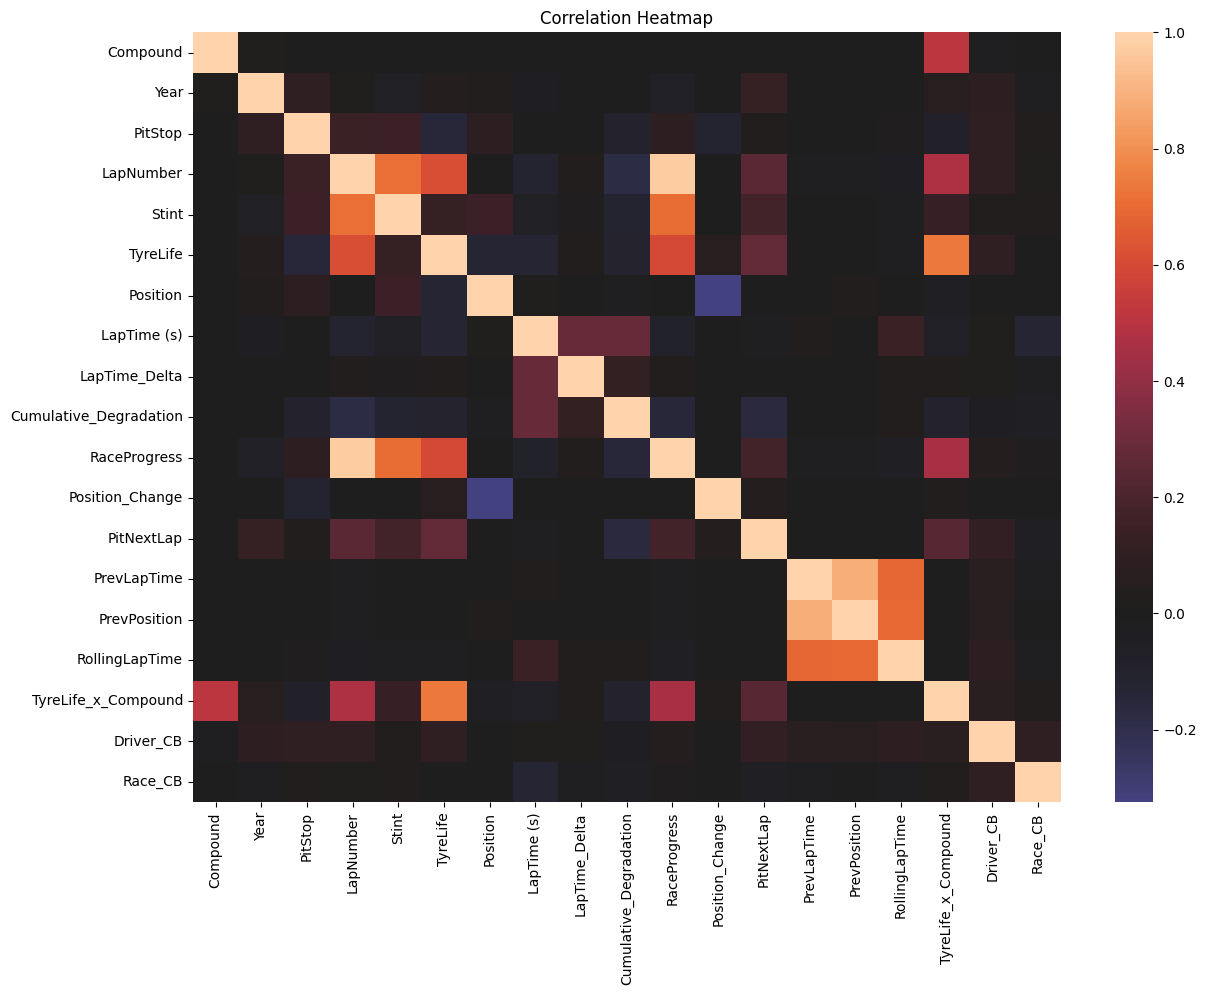

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns only
corr_matrix = train_data.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    #cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
cat_cols = train_data.select_dtypes(include='object').columns.tolist()
cat_cols

[]

In [25]:
from catboost import CatBoostClassifier

X=train_data.drop(columns=['PitNextLap'])
y=train_data['PitNextLap']
from sklearn.model_selection import train_test_split

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_f = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    task_type = 'GPU',
    loss_function='Logloss',
    eval_metric='F1',
    verbose=100
)

model_f.fit(X_train_f, y_train_f, cat_features=cat_cols)

0:	learn: 0.6504228	total: 195ms	remaining: 1m 37s
100:	learn: 0.6810994	total: 1.18s	remaining: 4.65s
200:	learn: 0.7021446	total: 2.02s	remaining: 3.01s
300:	learn: 0.7133566	total: 2.87s	remaining: 1.9s
400:	learn: 0.7219382	total: 3.75s	remaining: 926ms
499:	learn: 0.7271718	total: 4.59s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', task_type='GPU', verbose=100)

In [26]:
print(len(X_train_f.columns))
print(len(model_f.get_feature_importance()))

18
18


                   Feature  Importance
1                     Year   48.325675
4                    Stint   16.727897
5                 TyreLife    9.465284
8            LapTime_Delta    5.443521
10            RaceProgress    4.300871
7              LapTime (s)    2.445292
0                 Compound    2.382034
17                 Race_CB    2.354358
15     TyreLife_x_Compound    1.935072
3                LapNumber    1.556373
11         Position_Change    1.456926
9   Cumulative_Degradation    1.044792
2                  PitStop    0.904672
6                 Position    0.879810
16               Driver_CB    0.667696
14          RollingLapTime    0.066071
13            PrevPosition    0.025773
12             PrevLapTime    0.017883


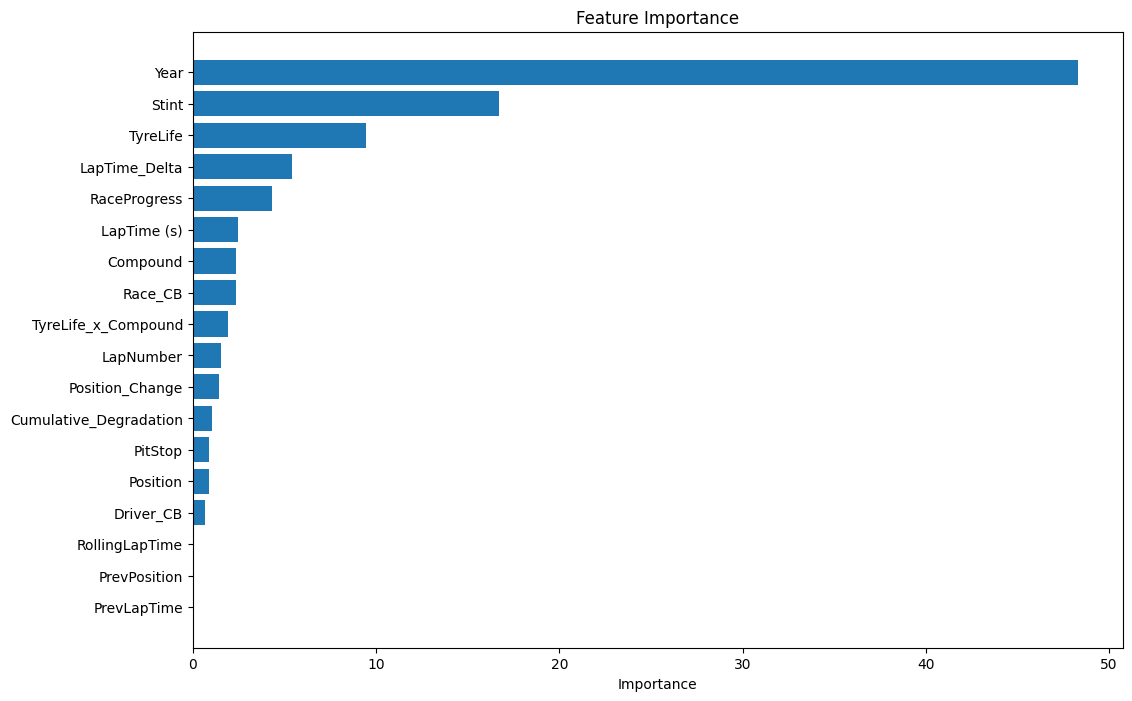

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_f.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

In [28]:
drop_cols = [
    'PitStop',
    'Driver_CB',
    'PrevLapTime',
    'RollingLapTime',
    'PrevPosition'
]

train_data.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [29]:
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# -----------------------------
# Features and Target
# -----------------------------
X = train_data.drop('PitNextLap', axis=1)

y = train_data['PitNextLap']

X_test = test_df.copy()

# -----------------------------
# Faster CV
# -----------------------------
skf = StratifiedKFold(
    n_splits=3,   # Faster than 5
    shuffle=True,
    random_state=42
)

# -----------------------------
# Optuna Objective
# -----------------------------
def objective(trial):

    # -----------------------------
    # Smart Search Space
    # -----------------------------
    depth = trial.suggest_int(
        "depth",
        4,
        8
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        0.01,
        0.08,
        log=True
    )

    params = {

        # High iterations + early stopping
        "iterations": 2000,

        "learning_rate": learning_rate,

        "depth": depth,

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            2,
            10
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.1,
            5
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            5
        ),

        # Faster GPU histogram
        "border_count": trial.suggest_int(
            "border_count",
            32,
            128
        ),

        # Imbalance
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            0.8,
            3
        ),

        # Extra speed tricks
        "bootstrap_type": "Bayesian",

        "grow_policy": "SymmetricTree",

        "leaf_estimation_iterations": 1,

        "od_type": "Iter",

        # Fixed
        "loss_function": "Logloss",

        "eval_metric": "F1",

        "verbose": 0,

        "random_state": 42,

        # GPU
        "task_type": "GPU",

        "devices": "0"
    }

    oof_probs = np.zeros(len(X))

    # -----------------------------
    # CV Loop
    # -----------------------------
    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = CatBoostClassifier(**params)

        model.fit(
            X_train,
            y_train,

            eval_set=(X_val, y_val),

            # Aggressive early stopping
            early_stopping_rounds=100,

            use_best_model=True,

            verbose=False
        )

        # Probability predictions
        preds = (
            model.predict_proba(X_val)[:, 1]
        )

        oof_probs[val_idx] = preds

    # -----------------------------
    # Threshold Optimization
    # -----------------------------
    threshold = trial.suggest_float(
        "threshold",
        0.35,
        0.65
    )

    final_preds = (
        oof_probs > threshold
    ).astype(int)

    score = f1_score(y, final_preds)

    return score

# -----------------------------
# Advanced Study
# -----------------------------
study = optuna.create_study(

    direction="maximize",

    sampler=TPESampler(
        seed=42
    ),

    pruner=MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5
    )
)

# -----------------------------
# Faster Optimization
# -----------------------------
study.optimize(
    objective,

    n_trials=20,   # Fast tuning first

    show_progress_bar=True
)

# -----------------------------
# Results
# -----------------------------
print("\n🔥 Best F1 Score:")
print(study.best_value)

print("\n🚀 Best Parameters:")
print(study.best_params)

# -----------------------------
# Final Model Training
# -----------------------------
best_params = study.best_params.copy()

# Remove threshold before model creation
best_threshold = best_params.pop("threshold")

model = CatBoostClassifier(

    **best_params,

    iterations=2000,

    loss_function='Logloss',

    eval_metric='F1',

    task_type='GPU',

    devices='0',

    verbose=200
)

model.fit(X, y)

# -----------------------------
# Test Predictions
# -----------------------------
test_probs = (
    model.predict_proba(X_test)[:, 1]
)

test_preds = (
    test_probs > best_threshold
).astype(int)

[I 2026-05-18 07:43:38,498] A new study created in memory with name: no-name-cf2cb748-c313-4b32-95ec-746db2c8f61d


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-18 07:44:05,364] Trial 0 finished with value: 0.6809956498236763 and parameters: {'depth': 5, 'learning_rate': 0.07220721098226064, 'l2_leaf_reg': 7.855951534491241, 'random_strength': 3.0334265725654794, 'bagging_temperature': 0.7800932022121826, 'border_count': 47, 'scale_pos_weight': 0.9277839467700388, 'threshold': 0.6098528437324806}. Best is trial 0 with value: 0.6809956498236763.
[I 2026-05-18 07:44:39,259] Trial 1 finished with value: 0.7462926531716954 and parameters: {'depth': 7, 'learning_rate': 0.04359666365651395, 'l2_leaf_reg': 2.1646759543664196, 'random_strength': 4.852558275593772, 'bagging_temperature': 4.162213204002109, 'border_count': 52, 'scale_pos_weight': 1.2000149278556214, 'threshold': 0.40502135295603015}. Best is trial 1 with value: 0.7462926531716954.
[I 2026-05-18 07:44:42,216] Trial 2 finished with value: 0.6501902943128411 and parameters: {'depth': 5, 'learning_rate': 0.02977846306223348, 'l2_leaf_reg': 5.455560149136926, 'random_strength': 1.

In [30]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import numpy as np

In [32]:
import optuna
import lightgbm
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score

from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# -----------------------------
# Features and target
# -----------------------------
X = train_data.drop('PitNextLap', axis=1)

y = train_data['PitNextLap']

X_test = test_df.copy()

groups = train_data['Race_CB']

# -----------------------------
# Faster GroupKFold
# -----------------------------
gkf = GroupKFold(n_splits=3)

# -----------------------------
# Optuna Objective
# -----------------------------
def objective(trial):

    # OOF + Test predictions
    oof_preds_lgb = np.zeros(len(X))

    # -----------------------------
    # Faster Search Space
    # -----------------------------
    max_depth = trial.suggest_int(
        "max_depth",
        4,
        8
    )

    num_leaves = trial.suggest_int(
        "num_leaves",
        31,
        255
    )

    params = {

        # Fixed high estimators
        # early stopping handles real count
        "n_estimators": 2000,

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "max_depth": max_depth,

        "num_leaves": num_leaves,

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            60
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            3,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            3,
            log=True
        ),

        # Faster GPU histograms
        "max_bin": trial.suggest_int(
            "max_bin",
            32,
            127
        ),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            0.8,
            3
        ),

        # Extra speed
        "objective": "binary",

        "boosting_type": "gbdt",

        "device": "gpu",

        "gpu_use_dp": False,

        "verbosity": -1,

        "random_state": 42
    }

    # -----------------------------
    # CV Loop
    # -----------------------------
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        print(f"\n🚀 Fold {fold+1}")

        X_train, X_val = (
            X.iloc[train_idx],
            X.iloc[val_idx]
        )

        y_train, y_val = (
            y.iloc[train_idx],
            y.iloc[val_idx]
        )

        model_lgb = LGBMClassifier(**params)

        # Train
        model_lgb.fit(

            X_train,
            y_train,

            eval_set=[(X_val, y_val)],

            eval_metric='binary_logloss',

            callbacks=[

                # Aggressive early stopping
                lightgbm.early_stopping(100),

                lightgbm.log_evaluation(0)
            ]
        )

        # Validation probabilities
        val_preds = (
            model_lgb.predict_proba(X_val)[:, 1]
        )

        oof_preds_lgb[val_idx] = val_preds

    # -----------------------------
    # Threshold Optimization
    # -----------------------------
    threshold = trial.suggest_float(
        "threshold",
        0.35,
        0.65
    )

    preds = (
        oof_preds_lgb > threshold
    ).astype(int)

    score = f1_score(y, preds)

    return score

# -----------------------------
# Advanced Study
# -----------------------------
study_lgb = optuna.create_study(

    direction="maximize",

    sampler=TPESampler(seed=42),

    pruner=MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5
    )
)

# -----------------------------
# Optimize
# -----------------------------
study_lgb.optimize(

    objective,

    n_trials=20,

    show_progress_bar=True
)

# -----------------------------
# Best Results
# -----------------------------
print("\n🔥 Best Score:")
print(study_lgb.best_value)

print("\n🚀 Best Parameters:")
print(study_lgb.best_params)

# -----------------------------
# Final Model
# -----------------------------
best_params_lgb = study_lgb.best_params.copy()

best_threshold_lgb = best_params_lgb.pop(
    "threshold"
)

# OOF + Test predictions
oof_preds_lgb = np.zeros(len(X))

test_preds_lgb = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train, X_val = (
        X.iloc[train_idx],
        X.iloc[val_idx]
    )

    y_train, y_val = (
        y.iloc[train_idx],
        y.iloc[val_idx]
    )

    model_lgb = LGBMClassifier(

        **best_params_lgb,

        n_estimators=2000,

        objective='binary',

        device='gpu',

        gpu_use_dp=False,

        random_state=42
    )

    model_lgb.fit(
        X_train,
        y_train
    )

    val_preds = (
        model_lgb.predict_proba(X_val)[:, 1]
    )

    oof_preds_lgb[val_idx] = val_preds

    test_preds_lgb += (

        model_lgb.predict_proba(X_test)[:, 1]

        / gkf.n_splits
    )

# Final tuned threshold
final_preds_lgb = (

    test_preds_lgb > best_threshold_lgb

).astype(int)

[I 2026-05-18 07:55:32,599] A new study created in memory with name: no-name-508be7e3-c628-41d0-9e5a-6c0613e923d1


  0%|          | 0/20 [00:00<?, ?it/s]


🚀 Fold 1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[660]	valid_0's binary_logloss: 0.298331

🚀 Fold 2
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[679]	valid_0's binary_logloss: 0.331704

🚀 Fold 3
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[835]	valid_0's binary_logloss: 0.304413
[I 2026-05-18 07:56:40,496] Trial 0 finished with value: 0.6949364155452492 and parameters: {'max_depth': 5, 'num_leaves': 244, 'learning_rate': 0.04582013868952863, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'min_child_samples': 17, 'reg_alpha': 0.001592075878523403, 'reg_lambda': 1.0275417738969417, 'max_bin': 89, 'scale_pos_weight': 2.3577596711513005, 'threshold': 0.3561753482887407}. Best is trial 0 with value: 0.6949364155452492.

🚀 Fold 1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[939]	valid_0's binary_logloss: 0.29021

🚀 Fold 2
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[925]	valid_0's binary_logloss: 0.313382

🚀 Fold 3
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1485]	valid_0's binary_logloss: 0.293831
[I 2026-05-18 07:59:40,006] Trial 1 finished with value: 0.7058575336087994 and parameters: {'max_depth': 8, 'num_leaves': 218, 'learning_rate': 0.01555110754210878, 'subsample': 0.7545474901621302, 'colsample_bytree': 0.7550213529560301, 'min_child_samples': 25, 'reg_alpha': 0.06677928149251665, 'reg_lambda': 0.03176326992019906, 'max_bin': 59, 'scale_pos_weight': 2.146076368389235, 'threshold': 0.39184815819561253}. Best is trial 1 with value: 0.7058575336087994.

🚀 Fold 1
Training until validation scores don't improve for 100 rounds
Early stopping, best ite

In [47]:
# -----------------------------
# Generate FINAL CatBoost OOF
# -----------------------------
oof_probs = np.zeros(len(X))

test_probs = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y)
):

    print(f"Fold {fold+1}")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostClassifier(

        **best_params,

        iterations=2000,

        loss_function='Logloss',

        eval_metric='F1',

        task_type='GPU',

        devices='0',

        verbose=0
    )

    model.fit(

        X_train,
        y_train,

        eval_set=(X_val, y_val),

        early_stopping_rounds=100,

        use_best_model=True,

        verbose=False
    )

    # OOF probabilities
    oof_probs[val_idx] = (

        model.predict_proba(X_val)[:, 1]
    )

    # Test probabilities
    test_probs += (

        model.predict_proba(X_test)[:, 1]

        / skf.n_splits
    )

Fold 1
Fold 2
Fold 3


In [48]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0
best_score = 0

for thresh in thresholds:

    preds = (final_oof > thresh).astype(int)

    score = f1_score(y, preds)

    if score > best_score:
        best_score = score
        best_thresh = thresh

print("Best Threshold:", best_thresh)
print("Best F1:", best_score)

Best Threshold: 0.5599999999999997
Best F1: 0.7508394788001478


In [49]:
final_oof = (

    0.6 * oof_probs +

    0.4 * oof_preds_lgb
)

final_test = (

    0.6 * test_probs +

    0.4 * test_preds_lgb
)

In [50]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"
)


In [51]:
final_preds = (
    final_test > best_thresh
).astype(int)

submission = pd.DataFrame({
    'id': sample_submission['id'],
    'PitNextLap': final_preds
})

submission.to_csv('submission.csv', index=False)

print("Submission file created!")

Submission file created!
